In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
data_filename = "diabetes_binary_health_indicators_BRFSS2015.csv"
df = pd.read_csv(data_filename)

# Taken from datacard on Kaggle, augmented by descriptions given in primary source.

column_descriptions = {
    'Diabetes_binary':"0 = no diabetes 1 = diabetes",
     'HighBP':"0 = no high BP 1 = high BP",
     'HighChol':"0 = no high cholesterol 1 = high cholesterol",
     'CholCheck':"0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years",
     'BMI':"Body Mass Index",
     'Smoker':"Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes",
     'Stroke':"(Ever told) you had a stroke. 0 = no 1 = yes",
     'HeartDiseaseorAttack':"coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes",
     'PhysActivity':"physical activity in past 30 days - not including job 0 = no 1 = yes",
     'Fruits':"Consume Fruit 1 or more times per day 0 = no 1 = yes ",
     'Veggies':"Consume Vegetables 1 or more times per day 0 = no 1 = yes",
     'HvyAlcoholConsump':"Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) 0 = no",
     'AnyHealthcare':"Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no 1 = yes",
     'NoDocbcCost':"Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes",
     'GenHlth':"Would you say that in general your health is: scale 1-5 1 = excellent 2 = very good 3 = good 4 = fair 5 = poor",
     'MentHlth':"Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? scale 1-30 days",
     'PhysHlth':"Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? scale 1-30 days",
     'DiffWalk':"Do you have serious difficulty walking or climbing stairs? 0 = no 1 = yes",
     'Sex':"0 = female 1 = male",
     'Age':"13-level age category (_AGEG5YR see codebook) 1 = 18-24, 2 = 25-29, 3 = 30-34, etc, 9 = 60-64, 13 = 80 or older",
     'Education':"Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary) 3 = Grades 9 through 11 (Some high school) 4 = Grade 12 or GED (High school graduate) 5 = College 1 year to 3 years (Some college or technical school) 6 = College 4 years or more (College graduate)",
     'Income':"Income scale (INCOME2 see codebook) scale 1-8. 1 = less than $10k, 2 = less than $15k, 3 = less than $20k, 4 = less than $25k, 5 = less than $35k, 6 = less than $50k, 7 = less than $75k, 8 = $75k or more"
}

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
df.nunique()

Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [6]:
df_description = df.describe()
df_description

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [7]:
# List of columns that have non-binary values
nonbinary_features = [col for col in df_description if df_description[col]['max'] > 2 and col!="Diabetes_binary"]
print(len(nonbinary_features))
print(nonbinary_features)

7
['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


In [8]:
# List of columns that have values less than or equal to 1, excluding target variable
binary_features = [col for col in df_description if df_description[col]['max'] <= 1 and col!="Diabetes_binary"]
print(len(binary_features))
print(binary_features)

14
['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']


In [9]:
df.value_counts("Diabetes_binary")


Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

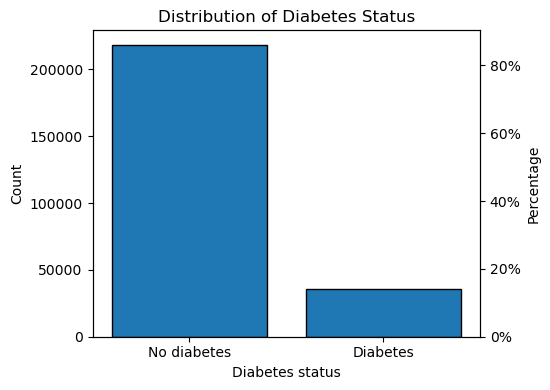

In [10]:
feature = 'Diabetes_binary'
data = df[feature].dropna()

fig, ax = plt.subplots(figsize=(5,4))
counts, bins, patches = ax.hist(
    data, bins=[-0.5, 0.5, 1.5], edgecolor='black', rwidth=0.8
)

# Left y-axis: counts (default)
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ['No diabetes', 'Diabetes'])
ax.set_xlabel('Diabetes status')
ax.set_ylabel('Count')
ax.set_title('Distribution of Diabetes Status')
ax.grid(False)
plt.tight_layout()

# Right y-axis: percentages
n = counts.sum()
ax2 = ax.twinx()
ax2.set_ylim(0, ax.get_ylim()[1] / n * 100 if n > 0 else 1)
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax2.set_ylabel('Percentage')

plt.show()


In [11]:
# --------------------------
# Manual label definitions
# --------------------------
binary_label_map = {
    'Diabetes_binary': ('No diabetes', 'Diabetes'),
    'HighBP': ('No high BP', 'High BP'),
    'HighChol': ('No high cholesterol', 'High cholesterol'),
    'CholCheck': ('No check in 5y', 'Checked in past 5y'),
    'Smoker': ('No ( <100 cigs )', 'Yes ( ≥100 cigs )'),
    'Stroke': ('No', 'Yes'),
    'HeartDiseaseorAttack': ('No CHD/MI', 'CHD or MI'),
    'PhysActivity': ('No', 'Yes'),
    'Fruits': ('<1×/day', '≥1×/day'),
    'Veggies': ('<1×/day', '≥1×/day'),
    'HvyAlcoholConsump': ('No', 'Heavy drinker'),
    'AnyHealthcare': ('No', 'Yes'),
    'NoDocbcCost': ('No', 'Yes'),
    'DiffWalk': ('No', 'Yes'),
    'Sex': ('Female', 'Male'),
}

# Discrete non-binary code → label maps (manually entered)
discrete_label_map = {
    'GenHlth': {
        1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor'
    },
    'Age': {
        1: '18–24', 2: '25–29', 3: '30–34', 4: '35–39', 5: '40–44',
        6: '45–49', 7: '50–54', 8: '55–59', 9: '60–64', 10: '65–69',
        11: '70–74', 12: '75–79', 13: '80+'
    },
    'Education': {
        1: 'No/Kindergarten', 2: 'Grades 1–8', 3: 'Grades 9–11',
        4: 'HS/GED', 5: 'Some college/tech', 6: 'College 4+ yrs'
    },
    'Income': {
        1: '<$10k', 2: '<$15k', 3: '<$20k', 4: '<$25k',
        5: '<$35k', 6: '<$50k', 7: '<$75k', 8: '$75k+'
    }
}

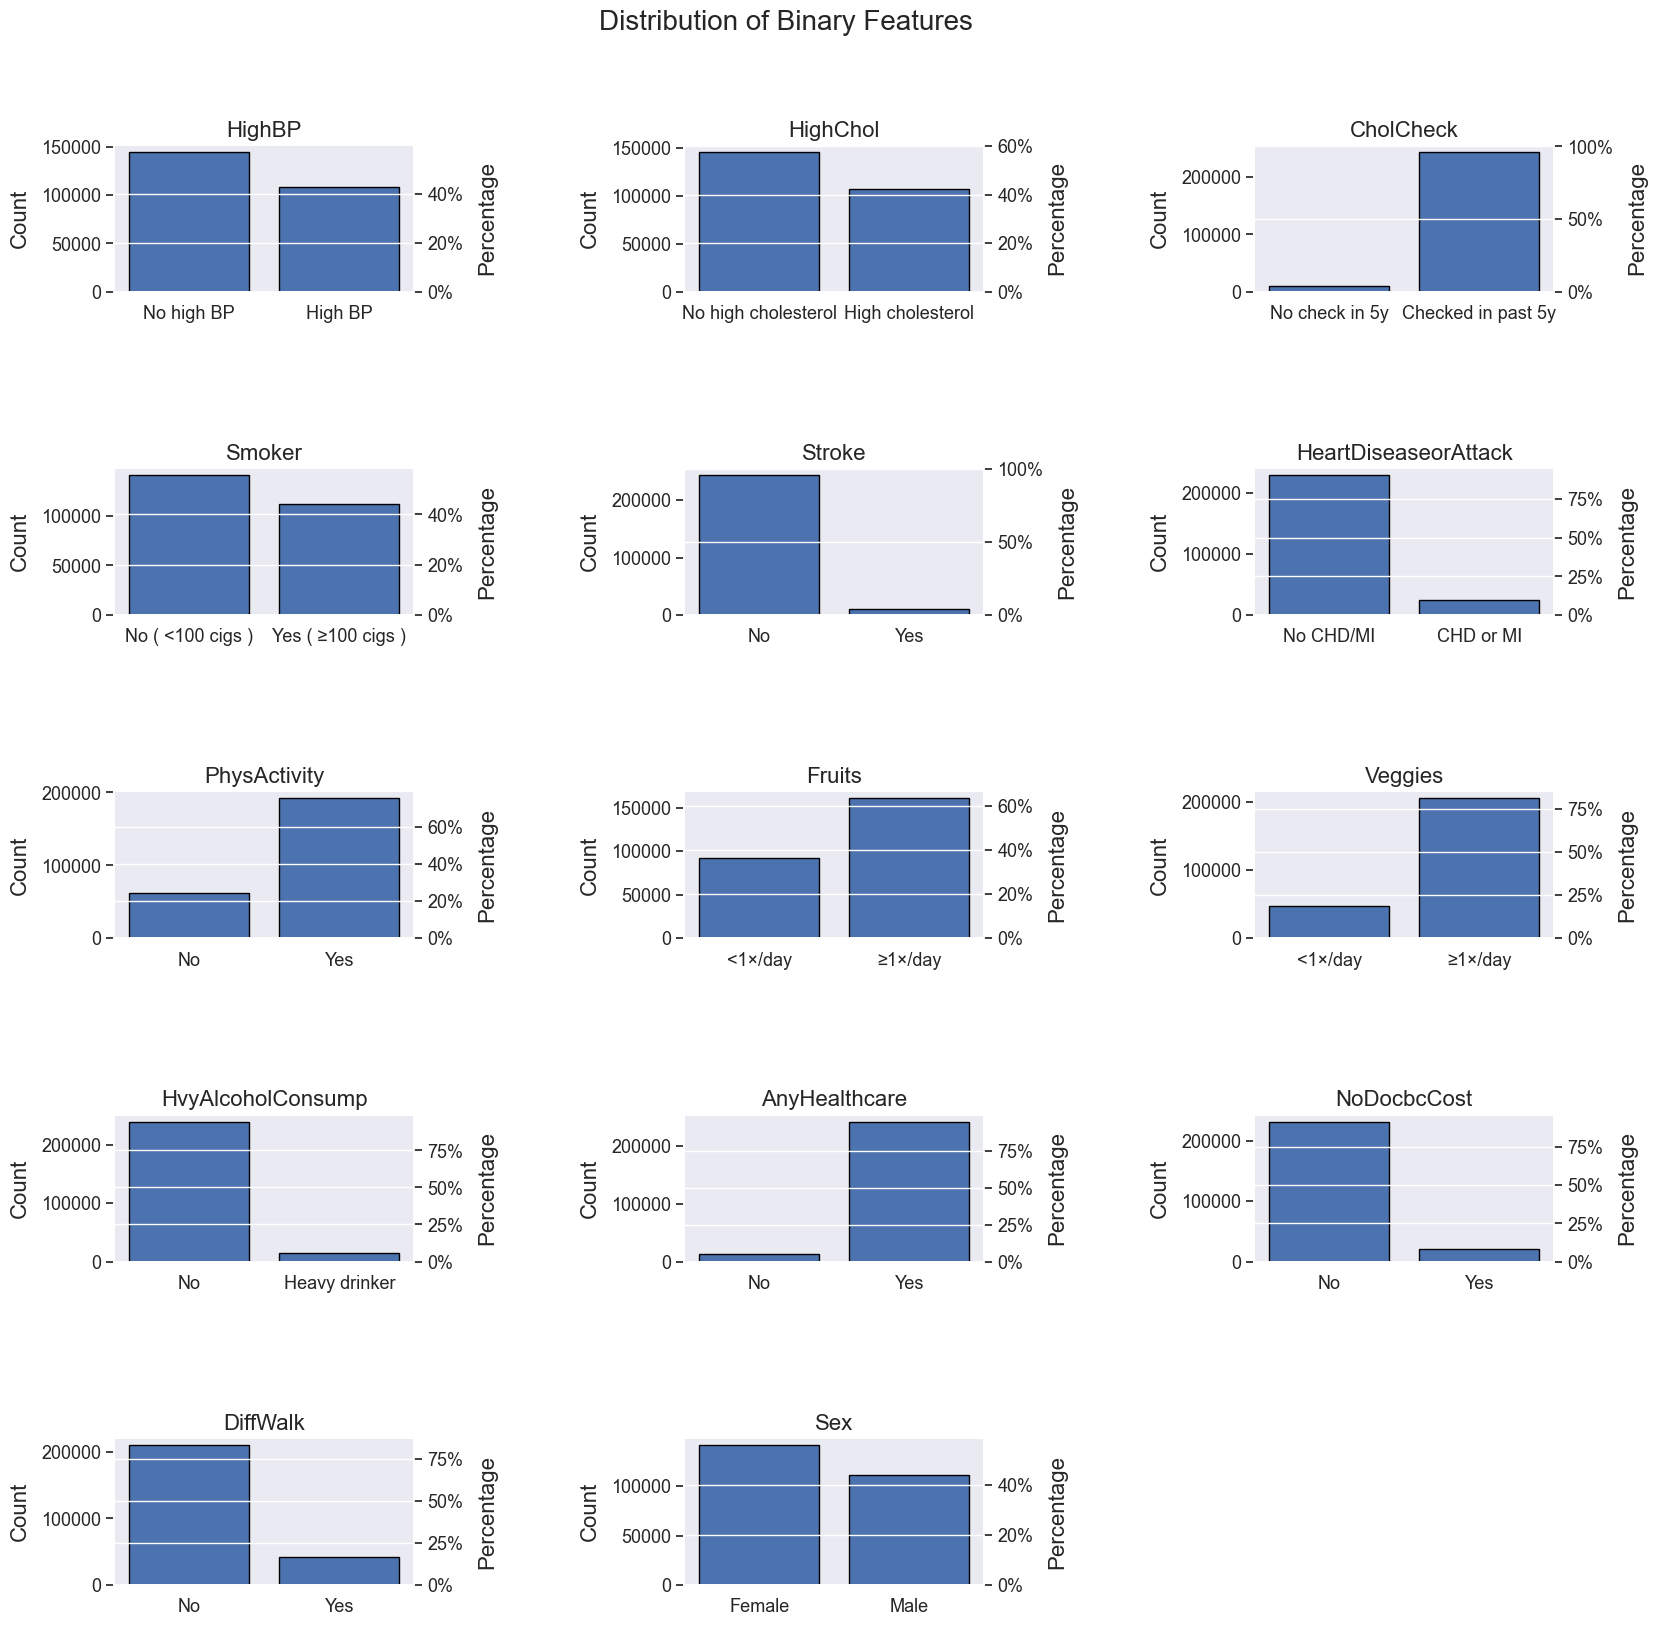

In [35]:
# ===============================
# TUNABLES — adjust these values
# ===============================
N_COLS = 3                 # number of subplot columns
PER_ROW_HEIGHT = 3.6       # inches per row (controls vertical size of each subplot)
FIG_WIDTH = 16             # overall figure width in inches
BIN_RWIDTH = 0.8           # bar width within each bin (1.0 touches edges)
LEFT_Y_LABELPAD = 8        # padding for left y-axis label
RIGHT_Y_LABELPAD = 10      # padding for right y-axis label
HSPACE = 1.2               # vertical spacing between rows of subplots
WSPACE = 0.90              # horizontal spacing between columns of subplots
MARGINS = dict(            # figure margins
    left=0.08, right=0.98, bottom=0.12, top=0.92
)

# --- Text size tunables (ALL increased) ---
TITLE_FONTSIZE = 20        # suptitle
SUBTITLE_FONTSIZE = 16     # per-axes title
AXIS_LABEL_FONTSIZE = 16   # x/y axis label text
TICK_LABEL_FONTSIZE = 13   # tick labels on both axes

# (Optional) set global defaults so EVERYTHING scales consistently
plt.rcParams.update({
    'axes.titlesize': SUBTITLE_FONTSIZE,
    'axes.labelsize': AXIS_LABEL_FONTSIZE,
    'xtick.labelsize': TICK_LABEL_FONTSIZE,
    'ytick.labelsize': TICK_LABEL_FONTSIZE,
})

# --- Compute grid and figure size based on tunables ---
ncols = N_COLS
nrows = int(np.ceil(len(binary_features) / ncols))
fig_height = max(10, PER_ROW_HEIGHT * nrows)

# --- Binary feature plots (3 columns, straight x labels, counts + % on right y-axis) ---
axes = df[binary_features].hist(
    bins=[-0.5, 0.5, 1.5],
    edgecolor='black',
    rwidth=BIN_RWIDTH,
    layout=(nrows, ncols),
    figsize=(FIG_WIDTH, fig_height)
)

axes_iter = np.ravel(axes)

# Hide any unused axes (when #features doesn't fill the grid)
for ax in axes_iter[len(binary_features):]:
    ax.set_visible(False)

for ax, col in zip(axes_iter[:len(binary_features)], binary_features):
    # Left axis: counts
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    if col in binary_label_map:
        ax.set_xticklabels(list(binary_label_map[col]), rotation=0, ha='center', fontsize=TICK_LABEL_FONTSIZE)
    else:
        ax.set_xticklabels([0, 1], rotation=0, ha='center', fontsize=TICK_LABEL_FONTSIZE)
    ax.set_xlabel('', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel('Count', labelpad=LEFT_Y_LABELPAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.grid(False)
    ax.set_title(col, fontsize=SUBTITLE_FONTSIZE)

    # Right axis: percentages
    n = df[col].dropna().shape[0]
    ymax = ax.get_ylim()[1]
    ax2 = ax.twinx()
    ax2.set_ylim(0, (ymax / n * 100) if n > 0 else 1)
    ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax2.set_ylabel('Percentage', labelpad=RIGHT_Y_LABELPAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax2.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)

# Spacing / layout
plt.subplots_adjust(hspace=HSPACE, wspace=WSPACE, **MARGINS)
plt.suptitle('Distribution of Binary Features', fontsize=TITLE_FONTSIZE, y=0.995)
plt.show()


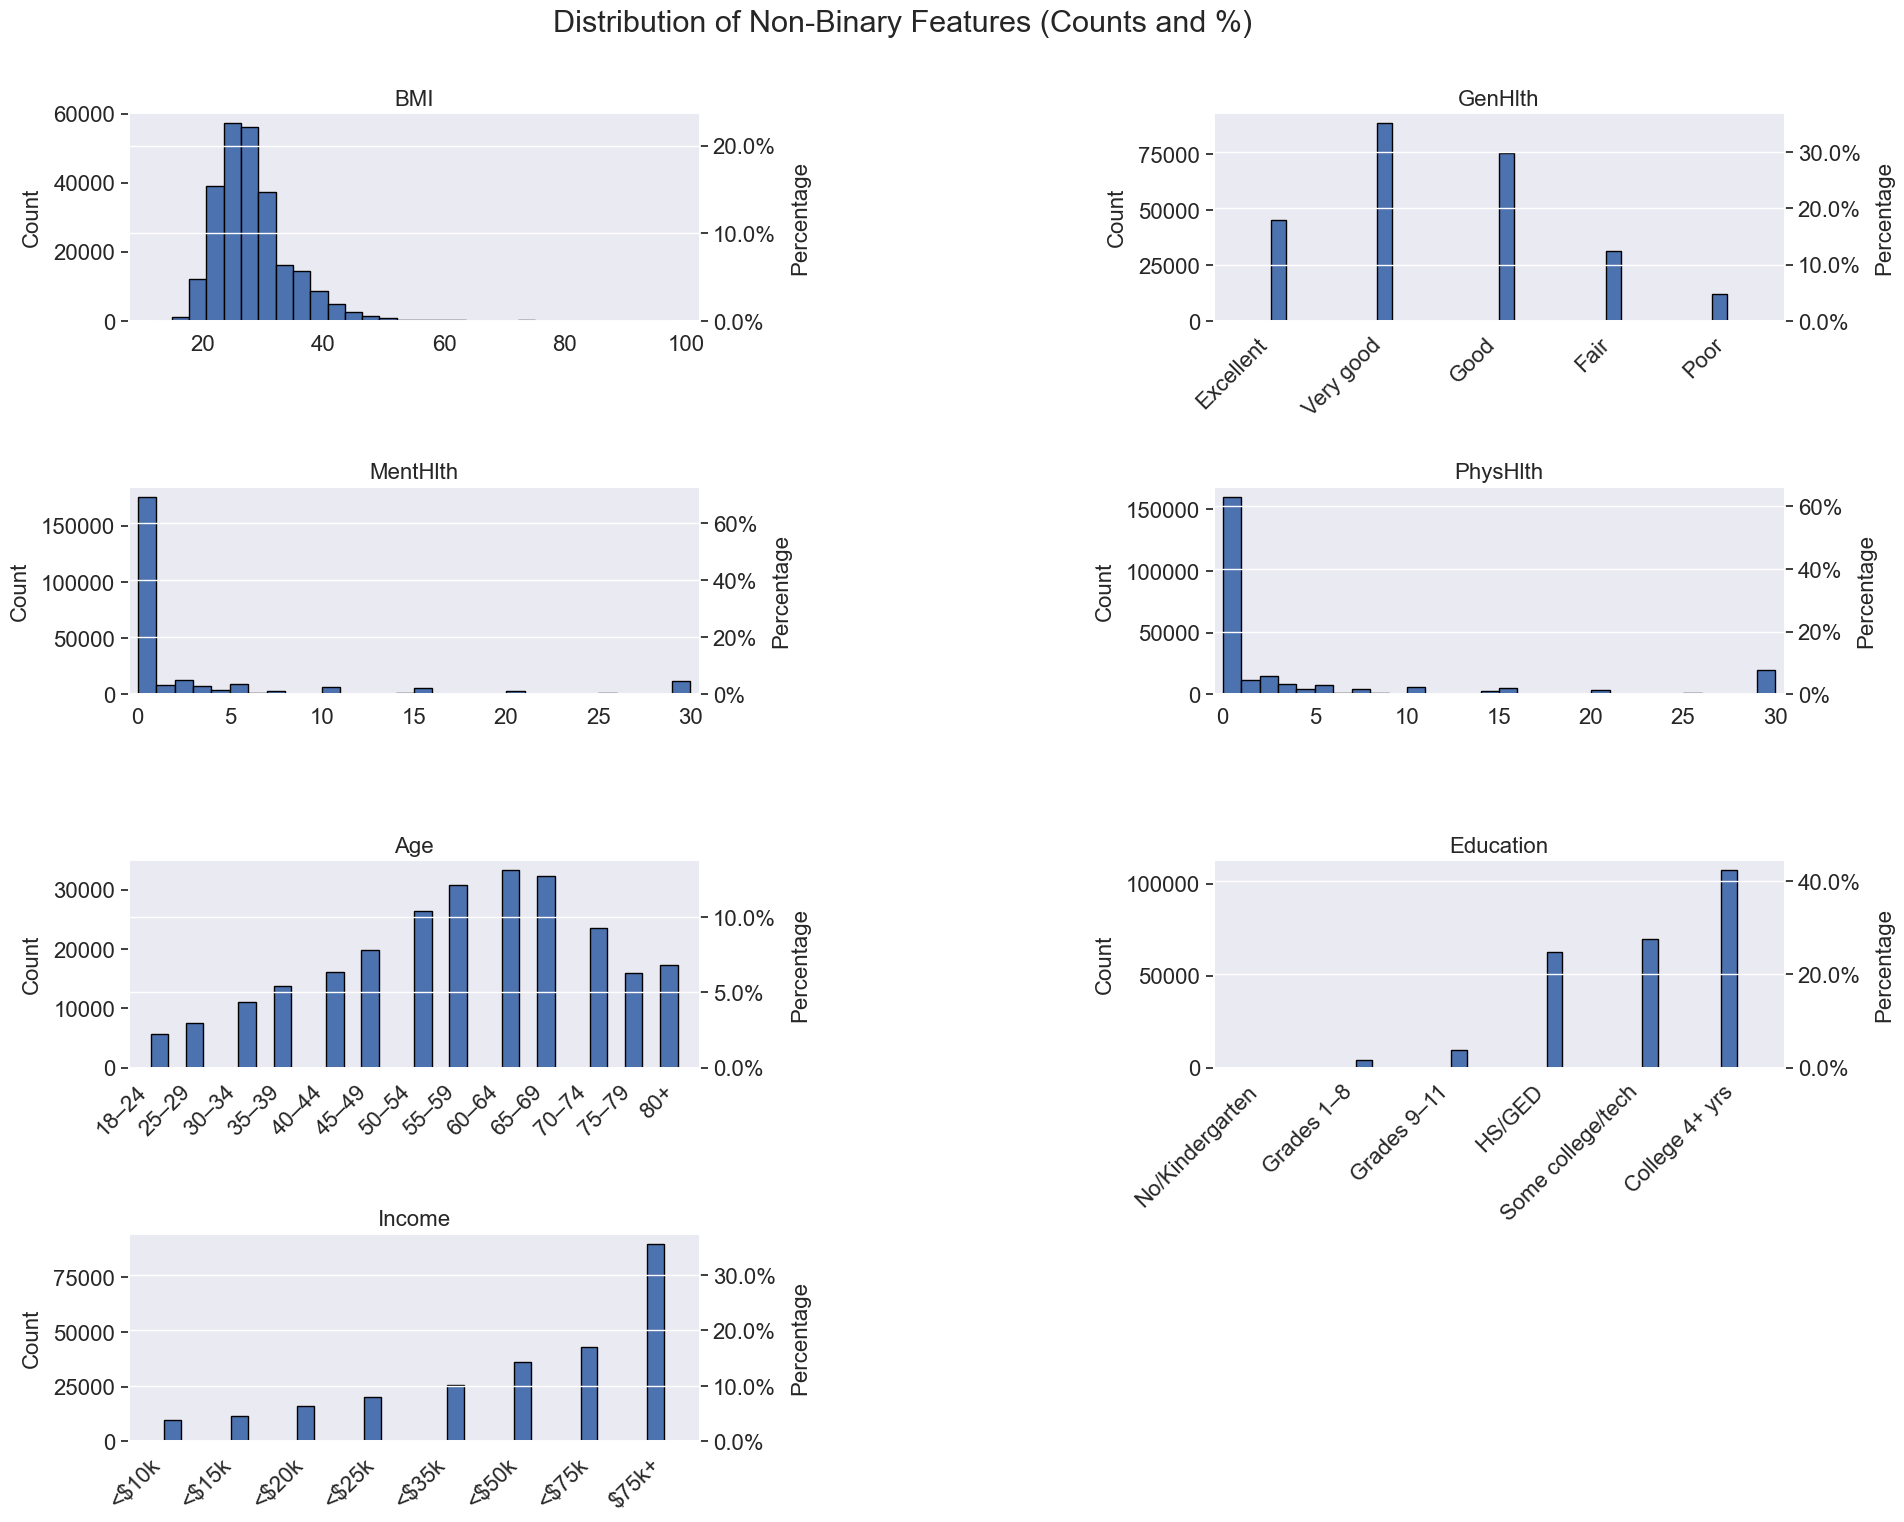

In [31]:
# ===============================
# TUNABLES — adjust these values
# ===============================
N_COLS = 2                 # number of subplot columns
PER_ROW_HEIGHT = 4.0       # inches per row (controls vertical size of each subplot)
FIG_WIDTH = 18             # overall figure width in inches
BINS = 30                  # number of bins for histograms
LEFT_Y_LABELPAD = 8        # padding for left y-axis label
RIGHT_Y_LABELPAD = 10      # padding for right y-axis label
HSPACE = 0.8               # vertical spacing between rows of subplots
WSPACE = 0.9               # horizontal spacing between columns of subplots
MARGINS = dict(            # figure margins
    left=0.07, right=0.99, bottom=0.10, top=0.93
)

# --- Text size tunables (ALL increased) ---
TITLE_FONTSIZE = 22        # suptitle
SUBTITLE_FONTSIZE = 16     # per-axes title (the column name)
AXIS_LABEL_FONTSIZE = 16   # x/y axis label text
TICK_LABEL_FONTSIZE = 16   # tick labels on both axes

# (Optional) set global defaults so EVERYTHING scales up consistently
plt.rcParams.update({
    'axes.titlesize': SUBTITLE_FONTSIZE,
    'axes.labelsize': AXIS_LABEL_FONTSIZE,
    'xtick.labelsize': TICK_LABEL_FONTSIZE,
    'ytick.labelsize': TICK_LABEL_FONTSIZE,
})

# --- Compute grid and figure size based on tunables ---
nrows = int(np.ceil(len(nonbinary_features) / N_COLS))
fig_height = max(10, PER_ROW_HEIGHT * nrows)

# =============================
#   NON-BINARY FEATURE PLOTS
#   (Counts on left, % on right; angled x labels for discrete maps)
# =============================
axes = df[nonbinary_features].hist(
    bins=BINS,
    edgecolor='black',
    layout=(nrows, N_COLS),
    figsize=(FIG_WIDTH, fig_height)
)
axes_iter = np.ravel(axes)

# Hide any unused axes if the grid isn't perfectly filled
for ax in axes_iter[len(nonbinary_features):]:
    ax.set_visible(False)

for ax, col in zip(axes_iter[:len(nonbinary_features)], nonbinary_features):
    # Left axis (counts)
    ax.set_xlabel('', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel('Count', labelpad=LEFT_Y_LABELPAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax.grid(False)
    ax.set_title(col, fontsize=SUBTITLE_FONTSIZE)

    # If this column has a manual discrete mapping, use it for x tick labels (angled)
    if 'discrete_label_map' in globals() and col in discrete_label_map:
        code_map = discrete_label_map[col]
        present_codes = sorted(
            int(c) for c in np.unique(df[col].dropna().astype(int)) if c in code_map
        )
        if len(present_codes) >= 2:
            ax.set_xticks(present_codes)
            ax.set_xticklabels([code_map[c] for c in present_codes],
                               rotation=45, ha='right', fontsize=TICK_LABEL_FONTSIZE)
            ax.set_xlim(min(present_codes)-0.5, max(present_codes)+0.5)

    # Optional: clearer ticks for day-count features if present
    if col in ['MentHlth', 'PhysHlth']:
        ticks = [0, 5, 10, 15, 20, 25, 30]
        ax.set_xticks(ticks)
        ax.set_xlim(-0.5, 30.5)

    # Right axis (percentages)
    n = df[col].dropna().shape[0]
    ymax = ax.get_ylim()[1]
    ax2 = ax.twinx()
    ax2.set_ylim(0, (ymax / n * 100) if n > 0 else 1)
    ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax2.set_ylabel('Percentage', labelpad=RIGHT_Y_LABELPAD, fontsize=AXIS_LABEL_FONTSIZE)
    ax2.tick_params(axis='y', labelsize=TICK_LABEL_FONTSIZE)

# Spacing so axes/labels don't collide between subplots
plt.subplots_adjust(hspace=HSPACE, wspace=WSPACE, **MARGINS)
plt.suptitle('Distribution of Non-Binary Features (Counts and %)', fontsize=TITLE_FONTSIZE, y=0.995)
plt.show()

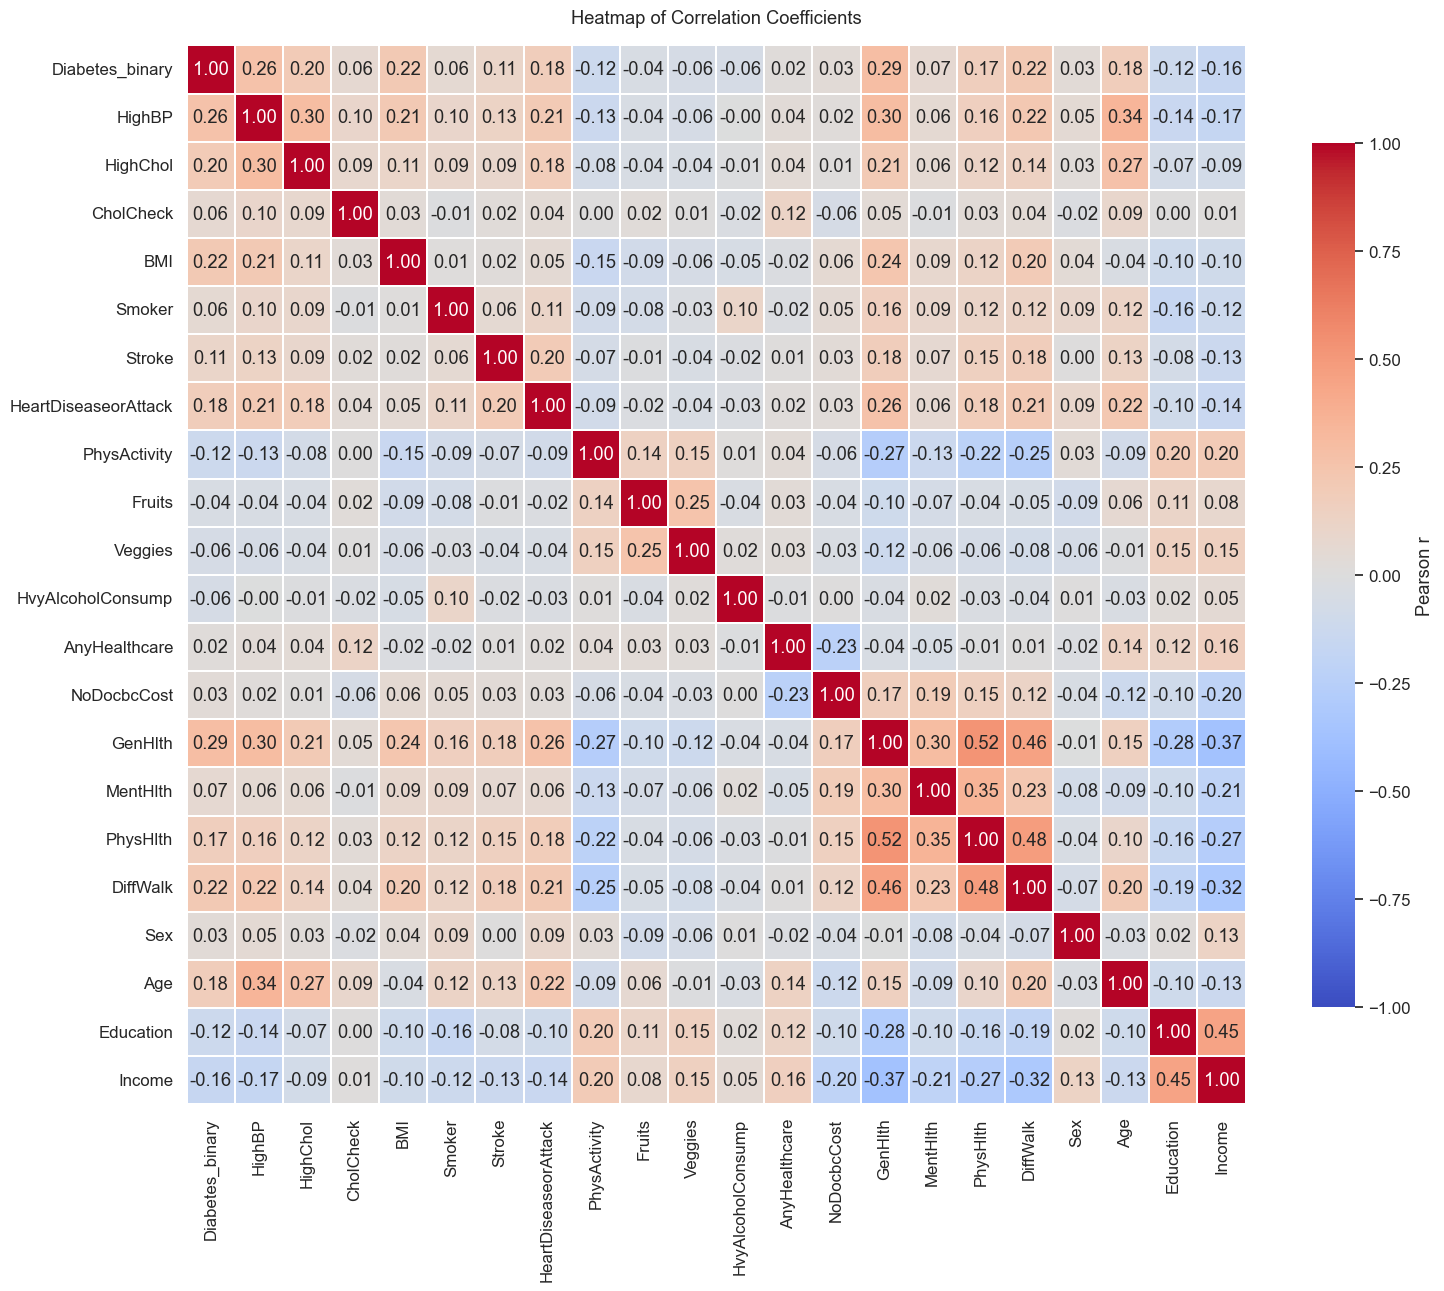

Correlations with Diabetes_binary (sorted by |r|):


,corr_with_Diabetes_binary
GenHlth,0.293569
HighBP,0.263129
DiffWalk,0.218344
BMI,0.216843
HighChol,0.200276
Age,0.177442
HeartDiseaseorAttack,0.177282
PhysHlth,0.171337
Income,-0.163919
Education,-0.124456


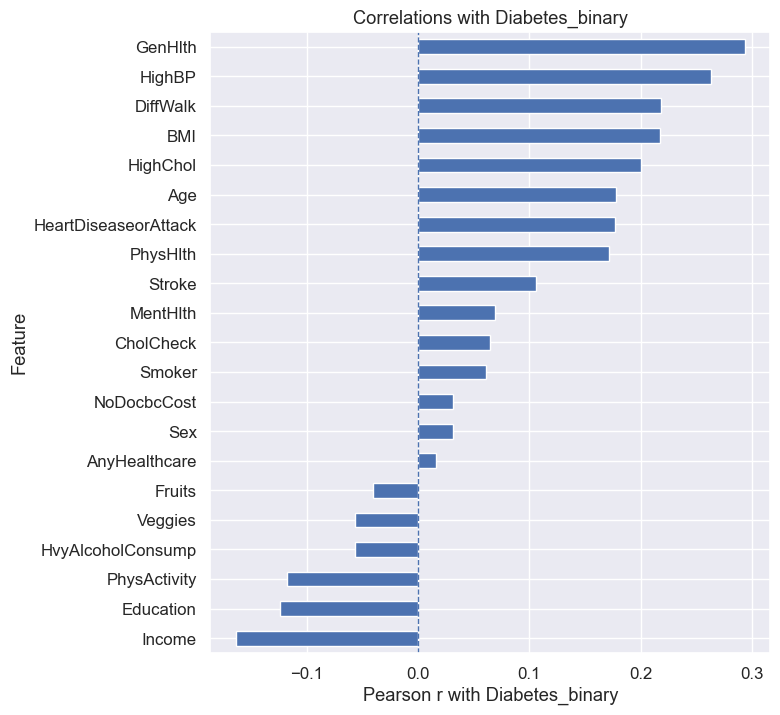

In [14]:
# Compute correlations on numeric columns only
corr_coefs = df.select_dtypes(include=[np.number]).corr(method='pearson')

# --- Full-grid heatmap (neat visual) ---
sns.set(font_scale=1.1)
fig_w = max(12, 0.7 * len(corr_coefs.columns))
fig_h = max(10, 0.7 * len(corr_coefs.columns))

plt.figure(figsize=(fig_w, fig_h))
plt.title('Heatmap of Correlation Coefficients', pad=16)
sns.heatmap(
    corr_coefs,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.6, "label": "Pearson r"}
)
plt.tight_layout()
plt.show()

# --- Correlations with Diabetes_binary only ---
if "Diabetes_binary" in corr_coefs.columns:
    diabetes_corr = (
        corr_coefs["Diabetes_binary"]
        .drop(labels=["Diabetes_binary"], errors="ignore")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    # 1) Print as a tidy table
    print("Correlations with Diabetes_binary (sorted by |r|):")
    display(diabetes_corr.to_frame("corr_with_Diabetes_binary"))

    # 2) Optional: quick bar plot (comment out if you only want the table)
    plt.figure(figsize=(8, max(4, 0.35 * len(diabetes_corr))))
    diabetes_corr.sort_values().plot(kind="barh")
    plt.xlabel("Pearson r with Diabetes_binary")
    plt.ylabel("Feature")
    plt.title("Correlations with Diabetes_binary")
    plt.axvline(0, lw=1, linestyle="--")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Diabetes_binary' was not found among numeric columns.")
